# Overview
This notebook contains the code for the chosen paper implementation on the dataset of "IAC debate corpus".

In [ ]:
!pip install nltk
!pip install numpy
!pip install tensorflow
!pip install gensim


In [ ]:
import pandas as pd
import numpy as np
import nltk
import gensim.downloader as api
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from nltk.tokenize import word_tokenize

# downloading nltk data (for tokenization)
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
# uploading the IAC dataset
data = pd.read_csv('IAC_data.csv')
data.columns = ['label', 'id', 'text']
print(data.head())

   label  id                                               text
0      1   1  Are you saying kill the chicken by shooting it...
1      1   2  It's usually easier to take the immoral path. ...
2      1   3  Archie proves, for the umpteenth time, that he...
3      0   4  Are you saying that without emotional investme...
4      0   5  So you're saying that the theory of evolution ...


In [ ]:
def chunk_text(text, n_chunks=2):
    words = word_tokenize(text)
    chunk_size = max(1, len(words) // n_chunks)
    chunks = [words[i:i + chunk_size] for i in range(0, len(words), chunk_size)]
    return chunks[:n_chunks]  # return only the specified number of chunks

data['chunks'] = data['text'].apply(lambda x: chunk_text(x, n_chunks=2))


In [ ]:
# loading pre-trained word embeddings
# 100-dimensional GloVe embeddings
word_vectors = api.load('glove-wiki-gigaword-100')

# seed words for each emotion category
emotion_seeds = {
    'anger': 'angry',
    'disgust': 'disgust',
    'fear': 'fear',
    'happiness': 'happy',
    'sadness': 'sad',
    'surprise': 'surprise'
}

# tp compute emotion vector for each word in the chunk
def compute_emotion_vector(word):
    if word in word_vectors:
        return np.array([word_vectors.similarity(word, seed) if seed in word_vectors else 0
                         for seed in emotion_seeds.values()])
    else:
        return np.zeros(len(emotion_seeds))

# to compute average emotion vector for each chunk
def compute_chunk_emotion_vector(chunk):
    emotion_vectors = [compute_emotion_vector(word) for word in chunk]
    return np.mean(emotion_vectors, axis=0)

# to apply to each chunk in the dataset
data['emotion_vectors'] = data['chunks'].apply(lambda chunks: [compute_chunk_emotion_vector(chunk) for chunk in chunks])


[==================================================] 100.0% 128.1/128.1MB downloaded


## Fixed N chunk n = 2

In [ ]:
n_chunks = 2
n_emotions = len(emotion_seeds)

# to pad or truncate emotion vectors to a fixed number of chunks
def pad_or_truncate(emotion_vectors, n_chunks, n_emotions):
    # if there are fewer chunks, pad with zeros; if more, truncate to the first n_chunks
    if len(emotion_vectors) < n_chunks:
        padding = [np.zeros(n_emotions) for _ in range(n_chunks - len(emotion_vectors))]
        emotion_vectors.extend(padding)
    return emotion_vectors[:n_chunks]

# applying padding/truncation to ensure each entry has exactly n_chunks
data['padded_emotion_vectors'] = data['emotion_vectors'].apply(lambda x: pad_or_truncate(x, n_chunks, n_emotions))

X = np.array(data['padded_emotion_vectors'].to_list())
y = data['label'].values

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Train LSTM model

In [ ]:
model = Sequential([
    LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

# train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4907 - loss: 0.6935 - val_accuracy: 0.5046 - val_loss: 0.6927
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4948 - loss: 0.6930 - val_accuracy: 0.5046 - val_loss: 0.6923
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5287 - loss: 0.6923 - val_accuracy: 0.5598 - val_loss: 0.6915
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5822 - loss: 0.6911 - val_accuracy: 0.5046 - val_loss: 0.6913
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5498 - loss: 0.6893 - val_accuracy: 0.5077 - val_loss: 0.6877
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5358 - loss: 0.6878 - val_accuracy: 0.6503 - val_loss: 0.6795
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6142 - loss: 0.6768 - val_accuracy: 0.6089 - val_loss: 0.6608
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6415 - loss: 0.6543 - val_accuracy: 0.6549 - v

In [ ]:
# evaluating the loss and accuracy
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6971 - loss: 0.5785 
Test Loss: 0.5843040943145752, Test Accuracy: 0.6947852969169617


## Fixed N chunk n = 3

In [ ]:
n_chunks = 3
n_emotions = len(emotion_seeds)

def pad_or_truncate(emotion_vectors, n_chunks, n_emotions):
    if len(emotion_vectors) < n_chunks:
        padding = [np.zeros(n_emotions) for _ in range(n_chunks - len(emotion_vectors))]
        emotion_vectors.extend(padding)
    return emotion_vectors[:n_chunks]

data['padded_emotion_vectors'] = data['emotion_vectors'].apply(lambda x: pad_or_truncate(x, n_chunks, n_emotions))

X = np.array(data['padded_emotion_vectors'].to_list())
y = data['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model = Sequential([
    LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5104 - loss: 0.6940 - val_accuracy: 0.5046 - val_loss: 0.6929
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5051 - loss: 0.6930 - val_accuracy: 0.5046 - val_loss: 0.6930
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4986 - loss: 0.6931 - val_accuracy: 0.5046 - val_loss: 0.6922
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5118 - loss: 0.6934 - val_accuracy: 0.5061 - val_loss: 0.6925
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5174 - loss: 0.6927 - val_accuracy: 0.5046 - val_loss: 0.6919
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5080 - loss: 0.6921 - val_accuracy: 0.5138 - val_loss: 0.6907
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5402 - loss: 0.6904 - val_accuracy: 0.5383 - val_loss: 0.6875
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5457 - loss: 0.6856 - val_accuracy: 0.4954 - v

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6754 - loss: 0.6099 
Test Loss: 0.6063265800476074, Test Accuracy: 0.6779140830039978


## Fixed N chunk n = 4

In [ ]:
n_chunks = 4
n_emotions = len(emotion_seeds)

def pad_or_truncate(emotion_vectors, n_chunks, n_emotions):
    if len(emotion_vectors) < n_chunks:
        padding = [np.zeros(n_emotions) for _ in range(n_chunks - len(emotion_vectors))]
        emotion_vectors.extend(padding)
    return emotion_vectors[:n_chunks]

data['padded_emotion_vectors'] = data['emotion_vectors'].apply(lambda x: pad_or_truncate(x, n_chunks, n_emotions))

X = np.array(data['padded_emotion_vectors'].to_list())
y = data['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = Sequential([
    LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4934 - loss: 0.6936 - val_accuracy: 0.5322 - val_loss: 0.6927
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5190 - loss: 0.6930 - val_accuracy: 0.4954 - val_loss: 0.6933
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5192 - loss: 0.6927 - val_accuracy: 0.5046 - val_loss: 0.6926
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4920 - loss: 0.6936 - val_accuracy: 0.6365 - val_loss: 0.6907
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5624 - loss: 0.6897 - val_accuracy: 0.4954 - val_loss: 0.6873
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5730 - loss: 0.6771 - val_accuracy: 0.5767 - val_loss: 0.6683
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5882 - loss: 0.6670 - val_accuracy: 0.5966 - val_loss: 0.6529
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6349 - loss: 0.6371 - val_accuracy: 0.6411 - 

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6573 - loss: 0.6148 
Test Loss: 0.608805239200592, Test Accuracy: 0.6702454090118408


## Fixed N chunk n = 5

In [ ]:
n_chunks = 5
n_emotions = len(emotion_seeds)

def pad_or_truncate(emotion_vectors, n_chunks, n_emotions):
    if len(emotion_vectors) < n_chunks:
        padding = [np.zeros(n_emotions) for _ in range(n_chunks - len(emotion_vectors))]
        emotion_vectors.extend(padding)
    return emotion_vectors[:n_chunks]

data['padded_emotion_vectors'] = data['emotion_vectors'].apply(lambda x: pad_or_truncate(x, n_chunks, n_emotions))

X = np.array(data['padded_emotion_vectors'].to_list())
y = data['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)


model = Sequential([
    LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5344 - loss: 0.6931 - val_accuracy: 0.4923 - val_loss: 0.6933
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5029 - loss: 0.6927 - val_accuracy: 0.5077 - val_loss: 0.6919
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5093 - loss: 0.6916 - val_accuracy: 0.4969 - val_loss: 0.6886
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5846 - loss: 0.6777 - val_accuracy: 0.6580 - val_loss: 0.6348
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6482 - loss: 0.6342 - val_accuracy: 0.6258 - val_loss: 0.6385
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6523 - loss: 0.6278 - val_accuracy: 0.6595 - val_loss: 0.6193
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6318 - loss: 0.6378 - val_accuracy: 0.6288 - val_loss: 0.6437
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6626 - loss: 0.6196 - val_accuracy: 0.6840 - v

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6749 - loss: 0.6051
Test Loss: 0.5928117036819458, Test Accuracy: 0.6855828166007996


## K fixed chunking, k = 2



In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

word_embeddings = word_vectors  # Word embeddings from GloVe or other sources

emotion_seeds = {
    "anger": "angry",
    "disgust": "disgust",
    "fear": "fear",
    "happy": "happy",
    "sad": "sad",
    "surprise": "surprised"
}

# to compute emotion vector for a word based on GloVe embeddings
def compute_emotion_vector_for_word(word, emotion_seeds, word_embeddings):
    if word in word_embeddings:
        word_vector = word_embeddings[word]
        emotion_vector = []
        for emotion, seed_word in emotion_seeds.items():
            if seed_word in word_embeddings:
                seed_vector = word_embeddings[seed_word]
                sim = cosine_similarity([word_vector], [seed_vector])[0][0]
                emotion_vector.append(sim)
            else:
                # if seed word is not found, we append zero for that emotion
                emotion_vector.append(0)
        return np.array(emotion_vector)
    else:
        # if the word is not in the GloVe embeddings then return zero vector for emotions
        return np.zeros(len(emotion_seeds))

# to split the text into fixed-length chunks
def fixed_k_chunking(text, k):
    words = text.split()  # split sentence into words and generate chunks of size k
    chunks = [words[i:i + k] for i in range(0, len(words), k)]
    return chunks

def compute_emotion_vector_for_chunk(chunk, emotion_seeds, word_embeddings):
    emotion_vectors = []
    for word in chunk:
        emotion_vector = compute_emotion_vector_for_word(word, emotion_seeds, word_embeddings)
        emotion_vectors.append(emotion_vector)
    return np.mean(emotion_vectors, axis=0)

def pad_or_truncate(emotion_vectors, k):
    if len(emotion_vectors) < k:
        # pad with zero vectors if there are fewer chunks than k
        padding = [np.zeros(len(emotion_seeds)) for _ in range(k - len(emotion_vectors))]
        emotion_vectors.extend(padding)
    return emotion_vectors[:k]  # truncate if there are more than k chunks

def process_data_for_model(data, k, emotion_seeds, word_embeddings):
    emotion_vectors_list = []
    for text in data['text']:
        # chunk the sentence into fixed-length chunks of size k
        chunks = fixed_k_chunking(text, k)

        # compute emotion vectors for each chunk
        emotion_vectors = [compute_emotion_vector_for_chunk(chunk, emotion_seeds, word_embeddings) for chunk in chunks]

        emotion_vectors = pad_or_truncate(emotion_vectors, k)

        emotion_vectors_list.append(emotion_vectors)

    return np.array(emotion_vectors_list)



word_embeddings = {
    'happy': np.random.rand(300),
    'sad': np.random.rand(300),
    'angry': np.random.rand(300),
    'disgust': np.random.rand(300),
    'fear': np.random.rand(300),
    'surprised': np.random.rand(300),
}

k = 2

X = process_data_for_model(data, k, emotion_seeds, word_embeddings)

# labels for training
y = np.array(data['label'])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshaping the data for LSTM input — LSTM requires input to be in the shape of (samples, time_steps, features)
time_steps = X_train.shape[1]  # number of chunks
features = X_train.shape[2]    # number of emotions (6)

# reshaping to match LSTM input format
X_train = X_train.reshape((X_train.shape[0], time_steps, features))
X_test = X_test.reshape((X_test.shape[0], time_steps, features))

model = Sequential()

model.add(LSTM(64, input_shape=(time_steps, features), return_sequences=False))  # LSTM layer

# dropout layer for regularization
model.add(Dropout(0.2))

# add Dense output layer with 1 unit (binary classification)
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))




/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                        │ (None, 64)                  │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,241 (71.25 KB)

 Trainable params: 18,241 (71.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4903 - loss: 0.6934 - val_accuracy: 0.5046 - val_loss: 0.6931
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4935 - loss: 0.6933 - val_accuracy: 0.4954 - val_loss: 0.6932
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5032 - loss: 0.6932 - val_accuracy: 0.4954 - val_loss: 0.6932
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5071 - loss: 0.6931 - val_accuracy: 0.5046 - val_loss: 0.6931
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5018 - loss: 0.6931 - val_accuracy: 0.4954 - val_loss: 0.6932
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5058 - loss: 0.6931 - val_accuracy: 0.4954 - val_loss: 0.6932
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5020 - loss: 0.6931 - val_accuracy: 0.5046 - val_loss: 0.6931
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5023 - loss: 0.6930 - val_accuracy: 0.5046 - v

In [ ]:
# evaluating the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4843 - loss: 0.6932 
Test Loss: 0.6931495666503906
Test Accuracy: 0.49539875984191895


### Plot of loss and accuracy

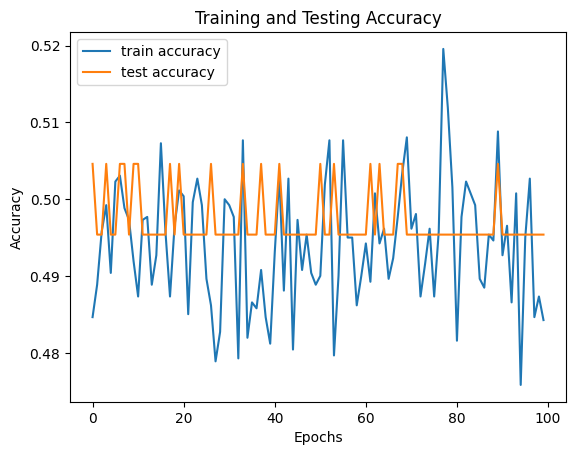

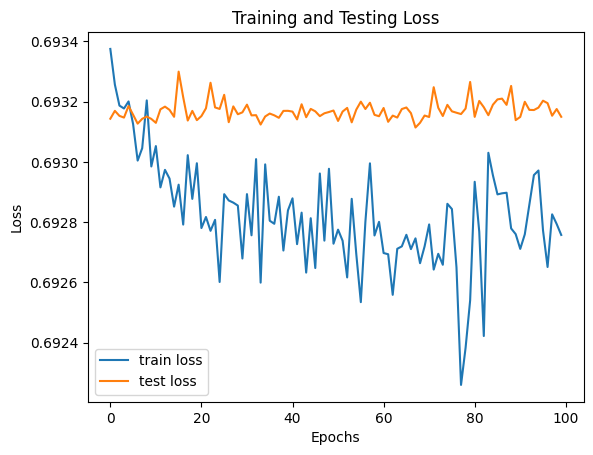

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='test accuracy')
plt.title('Training and Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='test loss')
plt.title('Training and Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


## FOR K = 3

In [ ]:
k = 3

X = process_data_for_model(data, k, emotion_seeds, word_embeddings)

y = np.array(data['label'])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

time_steps = X_train.shape[1]
features = X_train.shape[2]

X_train = X_train.reshape((X_train.shape[0], time_steps, features))
X_test = X_test.reshape((X_test.shape[0], time_steps, features))

model = Sequential()

model.add(LSTM(64, input_shape=(time_steps, features), return_sequences=False))

model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))



/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                       │ (None, 64)                  │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,241 (71.25 KB)

 Trainable params: 18,241 (71.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5070 - loss: 0.6932 - val_accuracy: 0.4923 - val_loss: 0.6932
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4832 - loss: 0.6934 - val_accuracy: 0.4923 - val_loss: 0.6933
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4994 - loss: 0.6932 - val_accuracy: 0.4923 - val_loss: 0.6932
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4992 - loss: 0.6932 - val_accuracy: 0.4923 - val_loss: 0.6932
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4843 - loss: 0.6934 - val_accuracy: 0.4923 - val_loss: 0.6934
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4953 - loss: 0.6931 - val_accuracy: 0.4923 - val_loss: 0.6933
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4807 - loss: 0.6934 - val_accuracy: 0.4923 - val_loss: 0.6934
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5094 - loss: 0.6931 - val_accuracy: 0.4923 - 

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4834 - loss: 0.6938
Test Loss: 0.6945711374282837
Test Accuracy: 0.49233129620552063


## For K = 4

In [ ]:
k = 4

X = process_data_for_model(data, k, emotion_seeds, word_embeddings)

y = np.array(data['label'])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

time_steps = X_train.shape[1]
features = X_train.shape[2]

X_train = X_train.reshape((X_train.shape[0], time_steps, features))
X_test = X_test.reshape((X_test.shape[0], time_steps, features))

model = Sequential()

model.add(LSTM(64, input_shape=(time_steps, features), return_sequences=False))

model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))



Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5038 - loss: 0.6933 - val_accuracy: 0.5031 - val_loss: 0.6931
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5038 - loss: 0.6933 - val_accuracy: 0.5031 - val_loss: 0.6931
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5144 - loss: 0.6931 - val_accuracy: 0.4954 - val_loss: 0.6932
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4919 - loss: 0.6933 - val_accuracy: 0.4954 - val_loss: 0.6933
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4834 - loss: 0.6933 - val_accuracy: 0.4954 - val_loss: 0.6934
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5120 - loss: 0.6928 - val_accuracy: 0.5031 - val_loss: 0.6931
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5032 - loss: 0.6932 - val_accuracy: 0.4954 - val_loss: 0.6933
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4825 - loss: 0.6932 - val_accuracy: 0.4954 - val_loss: 0.

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5200 - loss: 0.6931 
Test Loss: 0.6931799650192261
Test Accuracy: 0.5030674934387207


## For k = 5

In [ ]:
k = 5

X = process_data_for_model(data, k, emotion_seeds, word_embeddings)

y = np.array(data['label'])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

time_steps = X_train.shape[1]
features = X_train.shape[2]

X_train = X_train.reshape((X_train.shape[0], time_steps, features))
X_test = X_test.reshape((X_test.shape[0], time_steps, features))

model = Sequential()

model.add(LSTM(64, input_shape=(time_steps, features), return_sequences=False))

model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))



Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4946 - loss: 0.6930 - val_accuracy: 0.5046 - val_loss: 0.6931
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5116 - loss: 0.6931 - val_accuracy: 0.4954 - val_loss: 0.6932
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4906 - loss: 0.6933 - val_accuracy: 0.4954 - val_loss: 0.6932
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5070 - loss: 0.6932 - val_accuracy: 0.5046 - val_loss: 0.6931
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5109 - loss: 0.6933 - val_accuracy: 0.4954 - val_loss: 0.6932
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4713 - loss: 0.6934 - val_accuracy: 0.4954 - val_loss: 0.6933
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5052 - loss: 0.6931 - val_accuracy: 0.4954 - val_loss: 0.6932
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4959 - loss: 0.6931 - val_accuracy: 0.5046 - val_loss: 0.

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5172 - loss: 0.6967 
Test Loss: 0.694680392742157
Test Accuracy: 0.504601240158081
